## Creates HDF5 Files to store GW Data

Multiple HDF5 to single HDF5

In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import signal
from scipy import stats
from pylab import *
from matplotlib import cm
from scipy.stats import norm
from scipy.signal import welch
import nptdms as td


Change Directory to Data Location

In [2]:
exp_name = '4K GEN3'

In [3]:
data_name = 'run2'

In [4]:
os.chdir('C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/' + exp_name + '/' + data_name)

In [36]:
dirsize=len(os.listdir())

In [8]:
f_time = open(data_name + '-starttime.out', 'r')
time_str = f_time.readlines()[0]

FileNotFoundError: [Errno 2] No such file or directory: 'run2-starttime.out'

Create one file to store all hdf5 data onto local drive

In [7]:
fcomp=h5py.File(data_name + '.hdf5','w')
fcomp.create_group(data_name)

<HDF5 group "/run4-HG" (0 members)>

In [19]:
f=h5py.File(data_name + '-1D.hdf5','r+')

In [14]:
n=dirsize-1
for i in range(n):
    j = (i + 1) / n
    sys.stdout.write('\r')
    sys.stdout.write("[%-20s] %d%%" % ('='*int(20*j), 100*j))
    sys.stdout.flush()
    filestr= data_name+ '-channel4-'+str(i)+'.hdf5'
    fopen=h5py.File(filestr,'r')
    fcomp[data_name].create_dataset(str(i),data=fopen['Data'],chunks=True,compression="gzip", compression_opts=6)
    fopen.close()
    os.remove(filestr)
fcomp.close()

[====================] 100%

OSError: Unable to open file (unable to open file: name = 'run2-channel4-4.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

Creating New 1-Dimensional Data files 

In [15]:
fcomp=h5py.File(data_name + '.hdf5','r')
f1=h5py.File(data_name+'-1D.hdf5','w')
f1.attrs['starttime']= time_str
f1.create_group('X1')
f1.create_group('Y1')
f1.create_group('X2')
f1.create_group('Y2')
f1['X1'].create_dataset('Data',data=fcomp[data_name+'/0'][:,0],chunks=True,compression='gzip',compression_opts=6,maxshape=(None,))
f1['Y1'].create_dataset('Data',data=fcomp[data_name+'/0'][:,1],chunks=True,compression='gzip',compression_opts=6,maxshape=(None,))
f1['X2'].create_dataset('Data',data=fcomp[data_name+'/0'][:,2],chunks=True,compression='gzip',compression_opts=6,maxshape=(None,))
f1['Y2'].create_dataset('Data',data=fcomp[data_name+'/0'][:,3],chunks=True,compression='gzip',compression_opts=6,maxshape=(None,))


<HDF5 dataset "Data": shape (2000000,), type "<f8">

In [16]:
dirsize=len(fcomp[data_name])

In [17]:
for i in range(1,dirsize):
    dirstring=data_name+'/'+str(i)
    data=fcomp[dirstring][:,0]
    datasize=len(data)
    f1['X1/Data'].resize(f1['X1/Data'].shape[0]+data.shape[0],axis=0)
    f1['X1/Data'][-datasize:]=data
    j = (i + 1) / dirsize
    sys.stdout.write('\r')
    sys.stdout.write("[%-20s] %d%%" % ('='*int(20*j), 100*j))
    sys.stdout.flush()

[====================] 100%

In [18]:
for i in range(1,dirsize):
    dirstring=data_name+'/'+str(i)
    data=fcomp[dirstring][:,1]
    datasize=len(data)
    f1['Y1/Data'].resize(f1['Y1/Data'].shape[0]+data.shape[0],axis=0)
    f1['Y1/Data'][-datasize:]=data
    j = (i + 1) / dirsize
    sys.stdout.write('\r')
    sys.stdout.write("[%-20s] %d%%" % ('='*int(20*j), 100*j))
    sys.stdout.flush()

[====================] 100%

In [19]:
for i in range(1,dirsize):
    dirstring=data_name+'/'+str(i)
    data=fcomp[dirstring][:,2]
    datasize=len(data)
    f1['X2/Data'].resize(f1['X2/Data'].shape[0]+data.shape[0],axis=0)
    f1['X2/Data'][-datasize:]=data
    j = (i + 1) / dirsize
    sys.stdout.write('\r')
    sys.stdout.write("[%-20s] %d%%" % ('='*int(20*j), 100*j))
    sys.stdout.flush()

[====================] 100%

In [20]:
for i in range(1,dirsize):
    dirstring=data_name+'/'+str(i)
    data=fcomp[dirstring][:,3]
    datasize=len(data)
    f1['Y2/Data'].resize(f1['Y2/Data'].shape[0]+data.shape[0],axis=0)
    f1['Y2/Data'][-datasize:]=data
    j = (i + 1) / dirsize
    sys.stdout.write('\r')
    sys.stdout.write("[%-20s] %d%%" % ('='*int(20*j), 100*j))
    sys.stdout.flush() 
f1.close()

[====================] 100%

In [28]:
fcomp.close()
os.remove(data_name + '.hdf5')

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'run2.hdf5'

 Phase and Magnitude Data

In [ ]:
f = h5py.File(data_name+'-1D.hdf5','r+')

channel_1X=f['X1/Data']
channel_1Y=f['Y1/Data']
channel_2X=f['X2/Data']
channel_2Y=f['Y2/Data']

#f.create_group('Phase')
#f.create_group('Mag')

mag_data_1 = [np.sqrt(x**2+y**2) for x,y in zip(channel_1X,channel_1Y)]
f['Mag'].create_dataset('Mode 1', data=mag_data_1,chunks=True,compression="gzip", compression_opts=6)
del(mag_data_1)
print('mode 1 mag complete')

mag_data_2 = [np.sqrt(x**2+y**2) for x,y in zip(channel_2X,channel_2Y)]
f['Mag'].create_dataset('Mode 2', data=mag_data_2,chunks=True,compression="gzip", compression_opts=6)
del(mag_data_2)
print('mode 2 mag complete')

phase_data_1 = [np.arctan(y/x) for x,y in zip(channel_1X,channel_1Y)]
f['Phase'].create_dataset('Mode 1', data=phase_data_1,chunks=True,compression='gzip' ,compression_opts=6)
del(phase_data_1)
print('mode 1 phase complete')

phase_data_2 = [np.arctan(y/x) for x,y in zip(channel_2X,channel_2Y)]
f['Phase'].create_dataset('Mode 2', data=phase_data_2,chunks=True,compression='gzip' ,compression_opts=6)
del(phase_data_2)
print('mode 2 phase complete')

f.close()

## TDMS to HDF5 conversion

In [25]:
f = td.TdmsFile.read("run-4K-1.tdms")
f.groups()

[<TdmsGroup with path /'Demodulated Data'>]

In [26]:
f.properties

OrderedDict([('name', 'run-4K-1'),
             ('Title', 'DataTaking1'),
             ('Author', 'UserAdmin'),
             ('Start \nStart', '02/07/2100:34:52:.918')])

In [27]:
f['Demodulated Data'].channels()

[<TdmsChannel with path /'Demodulated Data'/'CH1-X'>,
 <TdmsChannel with path /'Demodulated Data'/'CH1-Y'>,
 <TdmsChannel with path /'Demodulated Data'/'CH2-X'>,
 <TdmsChannel with path /'Demodulated Data'/'CH2-Y'>,
 <TdmsChannel with path /'Demodulated Data'/'CH3-X'>,
 <TdmsChannel with path /'Demodulated Data'/'CH3-Y'>,
 <TdmsChannel with path /'Demodulated Data'/'CH4-X'>,
 <TdmsChannel with path /'Demodulated Data'/'CH4-Y'>,
 <TdmsChannel with path /'Demodulated Data'/'CH5-X'>,
 <TdmsChannel with path /'Demodulated Data'/'CH5-Y'>,
 <TdmsChannel with path /'Demodulated Data'/'CH6-X'>,
 <TdmsChannel with path /'Demodulated Data'/'CH6-Y'>,
 <TdmsChannel with path /'Demodulated Data'/'CH7-X'>,
 <TdmsChannel with path /'Demodulated Data'/'CH7-Y'>]

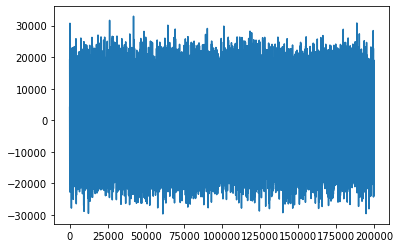

In [33]:
x = f['Demodulated Data']['CH1-X'][:]
plt.plot(x)

In [9]:
len(x)

200000

In [10]:
fn,Xw = welch(X1,fs=116.0,nperseg=2**12,window='hanning',scaling='density')

NameError: name 'X1' is not defined

NameError: name 'fn' is not defined

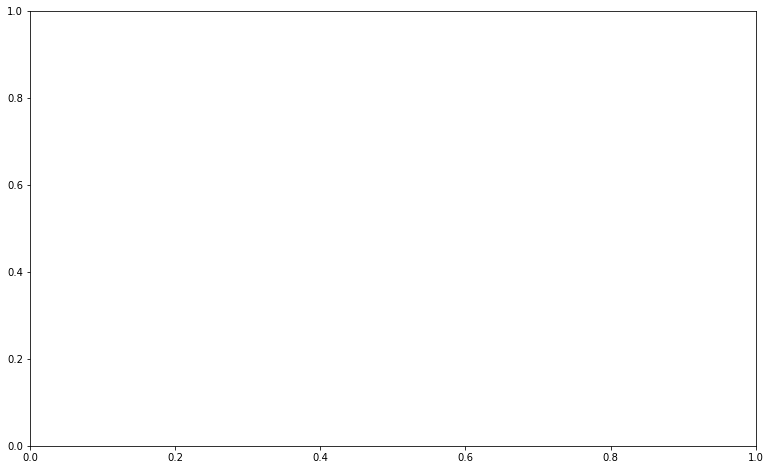

In [11]:
fig,ax = plt.subplots(1,figsize=(13,8))
ax.plot(fn,10*np.log10(Xw))

In [38]:
fcomp=h5py.File(data_name + '.hdf5','w')

In [39]:
f = td.TdmsFile.read("run-4K-0.tdms")

for channel in f['Demodulated Data'].channels():
    fcomp.create_group(channel.name)
    fcomp[channel.name].create_dataset('Data',data=f['Demodulated Data'][channel.name][:],chunks=True,compression='gzip',compression_opts=9,maxshape=(None,))
    

In [40]:
for key, value in f.properties.items():
    fcomp.attrs[key] = value
fcomp.attrs['starttime'] = '11:31:42.638 PM 7/1/2021'

In [41]:
#n=(dirsize-1)//2
n=1116
for i in range(1,n):
    j = (i + 1) / n
    sys.stdout.write('\r')
    sys.stdout.write("[%-20s] %d%%" % ('='*int(20*j), 100*j))
    sys.stdout.flush()
    filestr= 'run-4K-'+str(i)+'.tdms'
    fopen=td.TdmsFile.read(filestr,'r')
    for channel in fopen['Demodulated Data'].channels():
        data = channel[:]
        fcomp[channel.name + '/Data'].resize(fcomp[channel.name + '/Data'].shape[0]+data.shape[0],axis=0)
        fcomp[channel.name + '/Data'][-data.shape[0]:]=data
    fopen.close()
fcomp.close()

[====================] 100%

In [13]:
i=1
filestr= 'run-4K-'+str(i)+'.tdms'
fopen=td.TdmsFile.read(filestr,'r')
for channel in f['Demodulated Data'].channels():
    data = channel[:]


In [22]:
x1 = fcomp['CH1-X/Data'][:]

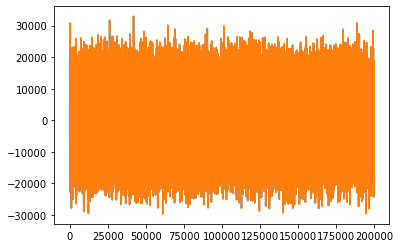

In [34]:
plot(x1)
plot(x)

## .OUT to HDF5 Conversion

In [2]:
exp_name = '4K GEN1b'

In [3]:
data_name = 'run0'

In [4]:
os.chdir('C:/Users/21958742/OneDrive - The University of Western Australia/UNI/PhD/High Frequency GW/Data Analysis/' + exp_name + '/' + data_name)

In [5]:
dirsize=len(os.listdir())

In [6]:
f_time = open(data_name + '-starttime.out', 'r')
time_str = f_time.readlines()[0]

Create one file to store all hdf5 data onto local drive

In [7]:
fcomp=h5py.File(data_name + '.hdf5','w')
fcomp.create_group(data_name)

<HDF5 group "/run4-HG" (0 members)>